# Process Diagnostics Comparison: GPQA vs MMLU-Pro (3 seeds each)

Computes the four process-level diagnostics (engagement, responsiveness, influence asymmetry, balance) for six baseline_v2 workbooks and compares them.

- **GPQA**: `baseline_v2_gpqa_s7/s17/s42.xlsx`
- **MMLU-Pro**: `baseline_v2_mmlu-pro_s7/s17/s42.xlsx`

Metrics use the categorical adaptation (answer letters), weighted by the LLM judge's `explanation_good` when a `Reasoning_Quality` sheet is present, else by confidence. Correctness = final answer == correct answer.

In [53]:
import re
from collections import Counter
from math import log
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, mannwhitneyu

EPS = 1e-9
METRICS = ['engagement', 'responsiveness', 'influence_asymmetry', 'balance']
AGENTS = ['Agent1', 'Agent2', 'Agent3']
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

In [54]:
def entropy(vals):
    vals = [v for v in vals if v and str(v) != 'nan']
    if len(vals) <= 1:
        return 0.0
    c = np.array(list(Counter(vals).values()), dtype=float)
    p = c / c.sum()
    return float(-sum(pi * log(pi) for pi in p if pi > 0) / log(len(vals)))

def corrected_balance(disp):
    n = len(disp)
    if n <= 1:
        return float('nan')
    steps = [disp[t-1] - disp[t] for t in range(1, n)]
    pos = [max(0.0, s) for s in steps]
    tot, mx = sum(pos), (max(pos) if pos else 0.0)
    if tot <= EPS:
        collapse = 1.0 if max(abs(s) for s in steps) <= EPS else 0.0
    else:
        collapse = 1.0 - mx / (tot + EPS)
    vol = 1.0 if n <= 2 else 1.0 - sum(steps[i-1]*steps[i] < 0 for i in range(1, len(steps))) / (n-2)
    return float(np.clip(collapse * vol, 0.0, 1.0))

def diagnostics(ans, qual):
    n = len(ans[0])
    eng, resp = [], []
    influence = np.zeros(n)
    for t in range(1, len(ans)):
        for a in range(n):
            old, new = ans[t-1][a], ans[t][a]
            if not old or not new:
                continue
            q = float(qual[t][a]) if qual[t][a] is not None else 0.5
            changed = old != new
            eng.append(q * float(changed))
            others = [ans[t-1][j] for j in range(n) if j != a and ans[t-1][j]]
            if others:
                old_sup = sum(o == old for o in others)
                new_sup = sum(o == new for o in others)
                resp.append(q * float(changed and new_sup > old_sup))
            for s in range(n):
                sa = ans[t-1][s]
                if s == a or not sa:
                    continue
                if changed and new == sa and old != sa:
                    influence[s] += q
    ti = float(influence.sum())
    if ti > EPS and n > 1:
        p = influence / ti
        asym = float(1.0 - (-sum(pi * log(pi) for pi in p if pi > 0)) / log(n))
    else:
        asym = 0.0
    disp = [entropy(r) for r in ans]
    return {'engagement': float(np.mean(eng)) if eng else np.nan,
            'responsiveness': float(np.mean(resp)) if resp else np.nan,
            'influence_asymmetry': asym,
            'balance': corrected_balance(disp)}

In [55]:
def load_judge_quality(path):
    """(question_no, round, agent) -> explanation_good, if the sheet exists."""
    try:
        rq = pd.read_excel(path, sheet_name='Reasoning_Quality')
    except (ValueError, KeyError, FileNotFoundError):
        return {}
    jq = {}
    for _, r in rq.iterrows():
        jq[(r['question_no'], int(r['round']), str(r['agent']))] = r.get('explanation_good')
    return jq

def parse_workbook(path):
    """One row per debate with recomputed metrics, correctness, and round-1 consensus."""
    xls = pd.ExcelFile(path)
    sheet = 'Debate_Traces' if 'Debate_Traces' in xls.sheet_names else 0
    df = pd.read_excel(path, sheet_name=sheet)
    rounds = sorted({int(m.group(1)) for c in df.columns if (m := re.match(r'R(\d+) Agent1 Answer', c))})
    jq = load_judge_quality(path)
    rows = []
    for _, r in df.iterrows():
        qno = r.get('Question #')
        ans, qual = [], []
        for rd in rounds:
            arow, qrow = [], []
            for ag in AGENTS:
                a = r.get(f'R{rd} {ag} Answer')
                c = r.get(f'R{rd} {ag} Conf')
                arow.append(None if pd.isna(a) else str(a).strip())
                jv = jq.get((qno, rd, ag))
                if jv is not None and not pd.isna(jv):
                    qrow.append(float(jv))
                else:
                    qrow.append(None if pd.isna(c) else float(c))
            ans.append(arow)
            qual.append(qrow)
        for a in range(3):
            for t in range(1, len(ans)):
                if not ans[t][a]:
                    ans[t][a] = ans[t-1][a]
                if qual[t][a] is None:
                    qual[t][a] = qual[t-1][a]
        d = diagnostics(ans, qual)
        corr, fin = r.get('Correct Answer'), r.get('Final Answer')
        d['is_correct'] = (int(str(corr).strip() == str(fin).strip())
                           if pd.notna(corr) and pd.notna(fin) else np.nan)
        d['r1_consensus'] = int(len({ans[0][a] for a in range(3) if ans[0][a]}) == 1)
        rows.append(d)
    return pd.DataFrame(rows)

In [56]:
_HET = 'C:/Proj1/docs/data/mmlu_hetero_cpu/seed_{}/qwen_mmlu_pro_debate_traces.xlsx'
FILES = {
    'MMLU paper': 'qwen_mmlu_faithful_s7.xlsx',
    'MMLU-7B-coop': 'C:/Proj1/docs/data/mmlu_original_cpu/seed_7/qwen_mmlu_pro_debate_traces.xlsx',
    'MMLU-hetero s7': _HET.format(7),
    'MMLU-hetero s17': _HET.format(17),
    'MMLU-hetero s42': _HET.format(42),
    'GPQA s7':      'baseline_v2_gpqa_s7.xlsx',
    'GPQA s17':     'baseline_v2_gpqa_s17.xlsx',
    'GPQA s42':     'baseline_v2_gpqa_s42.xlsx',
    'MMLU-Pro s7':  'baseline_v2_mmlu-pro_s7.xlsx',
    'MMLU-Pro s17': 'baseline_v2_mmlu-pro_s17.xlsx',
    'MMLU-Pro s42': 'baseline_v2_mmlu-pro_s42.xlsx',
}
data = {label: parse_workbook(path) for label, path in FILES.items()}
{label: len(df) for label, df in data.items()}

{'MMLU paper': 100,
 'MMLU-7B-coop': 100,
 'MMLU-hetero s7': 100,
 'MMLU-hetero s17': 100,
 'MMLU-hetero s42': 98,
 'GPQA s7': 100,
 'GPQA s17': 100,
 'GPQA s42': 100,
 'MMLU-Pro s7': 200,
 'MMLU-Pro s17': 200,
 'MMLU-Pro s42': 200}

## Table 1 — Distribution per file (mean ± std), accuracy, round-1 consensus

In [57]:
rows = []
for label, df in data.items():
    row = {'file': label, 'n': len(df),
           'accuracy': round(df['is_correct'].mean(), 3),
           'r1_consensus': round(df['r1_consensus'].mean(), 3)}
    for m in METRICS:
        row[m] = f"{df[m].mean():.3f} ± {df[m].std():.3f}"
    rows.append(row)
dist_table = pd.DataFrame(rows).set_index('file')
dist_table

,n,accuracy,r1_consensus,engagement,responsiveness,influence_asymmetry,balance
file,,,,,,,
MMLU paper,100,0.740,0.770,0.221 ± 0.118,0.018 ± 0.037,0.220 ± 0.325,0.110 ± 0.314
MMLU-7B-coop,100,0.670,0.900,0.049 ± 0.154,0.017 ± 0.057,0.012 ± 0.057,0.930 ± 0.256
MMLU-hetero s7,100,0.520,0.270,0.137 ± 0.118,0.068 ± 0.066,0.369 ± 0.358,0.300 ± 0.432
MMLU-hetero s17,100,0.550,0.300,0.135 ± 0.124,0.060 ± 0.060,0.321 ± 0.361,0.313 ± 0.441
MMLU-hetero s42,98,0.500,0.235,0.135 ± 0.114,0.059 ± 0.058,0.373 ± 0.331,0.232 ± 0.402
GPQA s7,100,0.380,0.750,0.081 ± 0.179,0.040 ± 0.085,0.048 ± 0.144,0.760 ± 0.429
GPQA s17,100,0.420,0.760,0.094 ± 0.196,0.041 ± 0.079,0.035 ± 0.104,0.773 ± 0.419
GPQA s42,100,0.400,0.810,0.083 ± 0.182,0.035 ± 0.074,0.045 ± 0.140,0.804 ± 0.396
MMLU-Pro s7,200,0.550,0.690,0.101 ± 0.179,0.042 ± 0.078,0.142 ± 0.292,0.684 ± 0.460


## Table 2 — Correlation with correctness (Spearman ρ per metric)

In [58]:
def composite(df):
    return (df['engagement'] + df['responsiveness'] + df['balance'] + (1 - df['influence_asymmetry'])) / 4

rows = []
for label, df in data.items():
    row = {'file': label}
    for m in METRICS:
        v = df[[m, 'is_correct']].dropna()
        rho, p = spearmanr(v[m], v['is_correct']) if len(v) > 3 else (np.nan, np.nan)
        row[m] = f"{rho:+.3f}{'*' if p < 0.05 else ''}"
    v = pd.DataFrame({'c': composite(df), 'y': df['is_correct']}).dropna()
    rho, p = spearmanr(v['c'], v['y'])
    row['avg_process'] = f"{rho:+.3f}{'*' if p < 0.05 else ''}"
    rows.append(row)
corr_table = pd.DataFrame(rows).set_index('file')
print('* = p < 0.05')
corr_table

* = p < 0.05


,engagement,responsiveness,influence_asymmetry,balance,avg_process
file,,,,,
MMLU paper,-0.314*,-0.348*,-0.342*,-0.188,+0.231*
MMLU-7B-coop,-0.146,-0.162,-0.165,+0.055,-0.043
MMLU-hetero s7,-0.280*,-0.155,-0.201*,+0.067,+0.055
MMLU-hetero s17,-0.244*,-0.168,-0.245*,+0.307*,+0.298*
MMLU-hetero s42,-0.344*,-0.076,-0.333*,+0.047,+0.113
GPQA s7,-0.127,-0.111,-0.089,+0.043,-0.028
GPQA s17,-0.009,-0.017,-0.018,+0.036,+0.011
GPQA s42,-0.187,-0.164,-0.100,+0.045,-0.089
MMLU-Pro s7,+0.027,-0.003,+0.031,-0.097,-0.063


## Table 3 — Correct vs incorrect group means (pooled by dataset)

In [59]:
pools = {
    'MMLU-paper (pooled)': pd.concat([data['MMLU paper']], ignore_index=True),
    # 'MMLU-7B-coop (pooled)': pd.concat([data['MMLU-7B-coop']], ignore_index=True),
    'MMLU-hetero (pooled)': pd.concat([data['MMLU-hetero s7'], data['MMLU-hetero s17'], data['MMLU-hetero s42']], ignore_index=True),
    'MMLU-Pro (pooled)': pd.concat([data['MMLU-Pro s7'], data['MMLU-Pro s17'], data['MMLU-Pro s42']], ignore_index=True),
    'GPQA (pooled)': pd.concat([data['GPQA s7'], data['GPQA s17'], data['GPQA s42']], ignore_index=True),
}
rows = []
for label, df in pools.items():
    for m in METRICS:
        cg = df[df.is_correct == 1][m].dropna()
        ig = df[df.is_correct == 0][m].dropna()
        p = mannwhitneyu(cg, ig).pvalue if len(cg) > 3 and len(ig) > 3 else np.nan
        rows.append({'dataset': label, 'metric': m,
                     'correct_mean': round(cg.mean(), 4),
                     'wrong_mean': round(ig.mean(), 4),
                     'diff': round(cg.mean() - ig.mean(), 4),
                     'MWU_p': round(p, 4)})
bucket_table = pd.DataFrame(rows)
bucket_table

,dataset,metric,correct_mean,wrong_mean,diff,MWU_p
0,MMLU-paper (pooled),engagement,0.1991,0.2821,-0.0830,0.0018
1,MMLU-paper (pooled),responsiveness,0.0114,0.0378,-0.0264,0.0005
2,MMLU-paper (pooled),influence_asymmetry,0.1646,0.3761,-0.2115,0.0007
3,MMLU-paper (pooled),balance,0.1351,0.0385,0.0967,0.0616
4,MMLU-hetero (pooled),engagement,0.1069,0.1675,-0.0606,0.0000
5,MMLU-hetero (pooled),responsiveness,0.0542,0.0716,-0.0174,0.0197
6,MMLU-hetero (pooled),influence_asymmetry,0.2829,0.4329,-0.1500,0.0000
7,MMLU-hetero (pooled),balance,0.3560,0.2005,0.1555,0.0104
8,MMLU-Pro (pooled),engagement,0.0923,0.1204,-0.0280,0.4625
9,MMLU-Pro (pooled),responsiveness,0.0397,0.0504,-0.0107,0.2136


## Table 4 — Pooled distribution & correlation summary (GPQA vs MMLU-Pro)

In [60]:
rows = []
for label, df in pools.items():
    cons = df[df.r1_consensus == 1]         # debates that reached consensus in round 1
    noncons = df[df.r1_consensus == 0]      # debates that did NOT
    row = {'dataset': label, 'n': len(df),
           'accuracy': round(df['is_correct'].mean(), 3),
           'r1_consensus': round(df['r1_consensus'].mean(), 3),
           # accuracy CONDITIONAL on round-1 consensus vs not:
           'r1_cons_acc': round(cons['is_correct'].mean(), 3) if len(cons) else float('nan'),
           'r1_noncons_acc': round(noncons['is_correct'].mean(), 3) if len(noncons) else float('nan')}
    for m in METRICS:
        row[f'{m}_mean'] = round(df[m].mean(), 3)
    v = pd.DataFrame({'c': composite(df), 'y': df['is_correct']}).dropna()
    rho, p = spearmanr(v['c'], v['y'])
    row['avg_process_rho'] = f"{rho:+.3f}{'*' if p < 0.05 else ''}"
    rows.append(row)
pooled_table = pd.DataFrame(rows).set_index('dataset')
# r1_cons_acc = P(correct | round-1 consensus); r1_noncons_acc = P(correct | no round-1 consensus)
pooled_table

,n,accuracy,r1_consensus,r1_cons_acc,r1_noncons_acc,engagement_mean,responsiveness_mean,influence_asymmetry_mean,balance_mean,avg_process_rho
dataset,,,,,,,,,,
MMLU-paper (pooled),100,0.740,0.770,0.805,0.522,0.221,0.018,0.220,0.110,+0.231*
MMLU-hetero (pooled),298,0.523,0.268,0.675,0.468,0.136,0.062,0.354,0.282,+0.163*
MMLU-Pro (pooled),600,0.552,0.688,0.562,0.529,0.105,0.044,0.122,0.675,-0.056
GPQA (pooled),300,0.400,0.773,0.418,0.338,0.086,0.039,0.042,0.779,-0.034


## Plots

Two views: (1) how the metric **distributions** differ between GPQA and MMLU-Pro, and (2) whether **correct vs wrong** debates separate on each metric within each dataset.

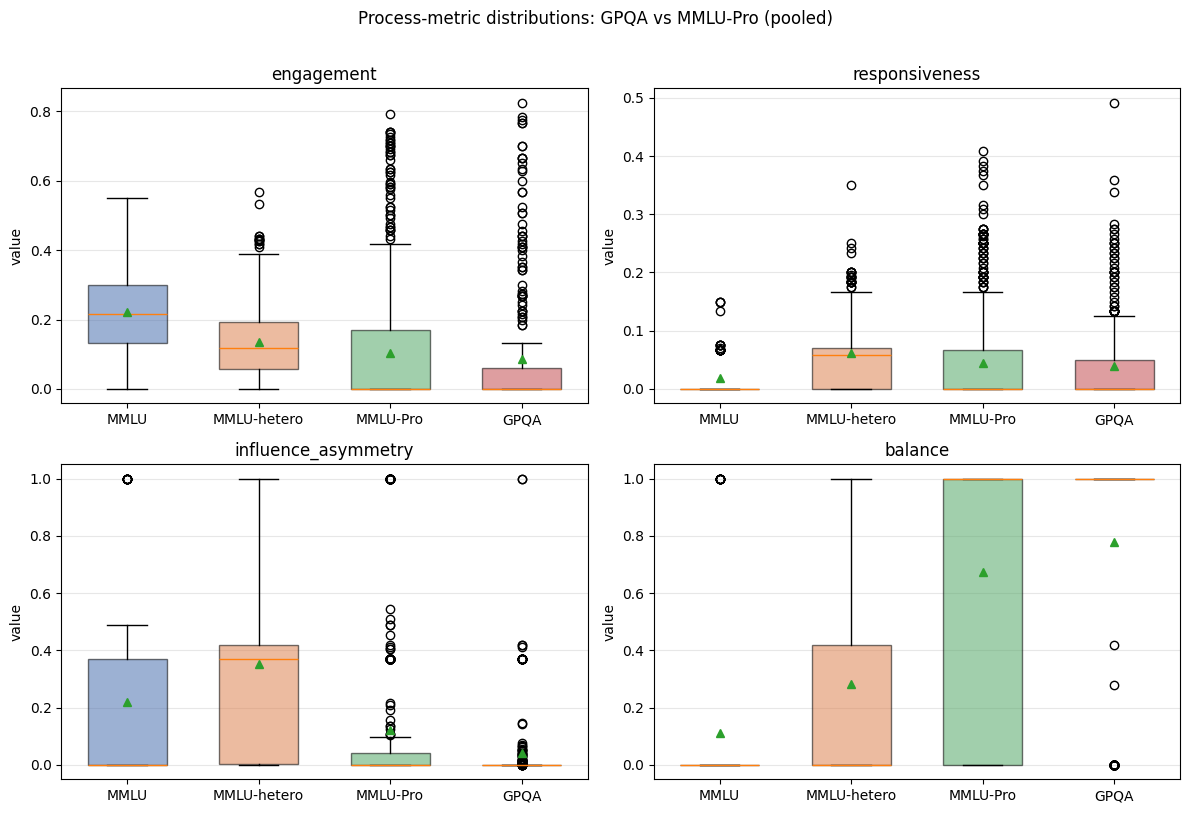

In [61]:
## Plot 1 — metric distributions: GPQA vs MMLU-Pro (pooled, 3 seeds each)
import matplotlib.pyplot as plt
mmlu = pools['MMLU-paper (pooled)']
mmlu_hetero = pools['MMLU-hetero (pooled)']
gpqa = pools['GPQA (pooled)']
mmlu_pro = pools['MMLU-Pro (pooled)']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, m in zip(axes.ravel(), METRICS):
    bp = ax.boxplot([mmlu[m].dropna(), mmlu_hetero[m].dropna(), mmlu_pro[m].dropna(), gpqa[m].dropna()], showmeans=True,
                    patch_artist=True, widths=0.6)
    for patch, col in zip(bp['boxes'], ['#4C72B0', '#DD8452', '#55A868', '#C44E52']):
        patch.set_facecolor(col); patch.set_alpha(0.55)
    ax.set_xticks([1, 2, 3, 4]); ax.set_xticklabels(['MMLU', 'MMLU-hetero', 'MMLU-Pro', 'GPQA'])
    ax.set_title(m); ax.set_ylabel('value'); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Process-metric distributions: GPQA vs MMLU-Pro (pooled)', y=1.01)
fig.tight_layout(); plt.show()

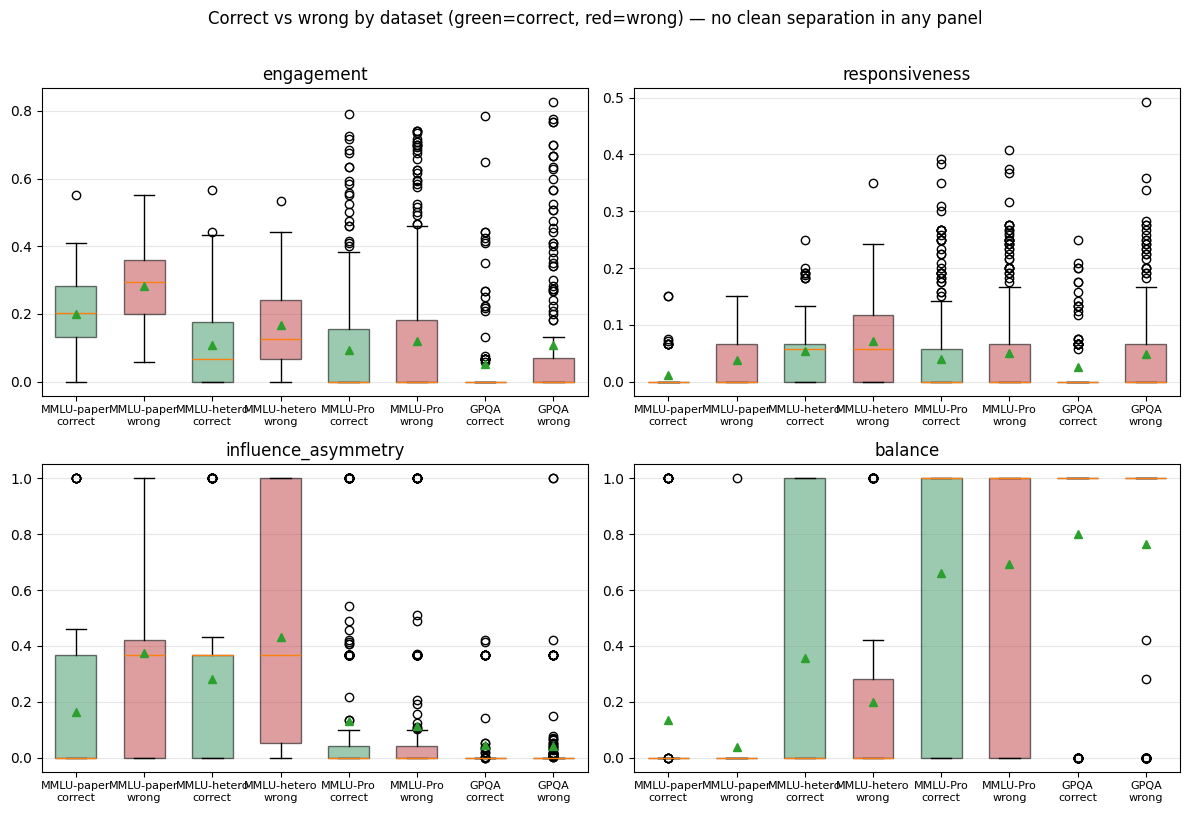

In [62]:
## Plot 2 — correct vs wrong overlays, per metric, per dataset
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, m in zip(axes.ravel(), METRICS):
    groups, labels, colors = [], [], []
    for dlabel, df in pools.items():
        ds = dlabel.split()[0]
        groups.append(df[df.is_correct == 1][m].dropna()); labels.append(f'{ds}\ncorrect'); colors.append('#4C9F70')
        groups.append(df[df.is_correct == 0][m].dropna()); labels.append(f'{ds}\nwrong');   colors.append('#C44E52')
    bp = ax.boxplot(groups, showmeans=True, patch_artist=True, widths=0.6)
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col); patch.set_alpha(0.55)
    ax.set_xticks(range(1, len(labels) + 1)); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(m); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Correct vs wrong by dataset (green=correct, red=wrong) — no clean separation in any panel', y=1.01)
fig.tight_layout(); plt.show()

['accuracy', 'r1_consensus', 'r1_cons_acc', 'engagement_mean', 'responsiveness_mean', 'influence_asymmetry_mean', 'balance_mean']
                        n  accuracy  r1_consensus  r1_cons_acc  r1_noncons_acc  engagement_mean  responsiveness_mean  influence_asymmetry_mean  balance_mean  \
dataset                                                                                                                                                        
MMLU-paper (pooled)   100     0.740         0.770        0.805           0.522            0.221                0.018                     0.220         0.110   
MMLU-hetero (pooled)  298     0.523         0.268        0.675           0.468            0.136                0.062                     0.354         0.282   
MMLU-Pro (pooled)     600     0.552         0.688        0.562           0.529            0.105                0.044                     0.122         0.675   
GPQA (pooled)         300     0.400         0.773        0.418        

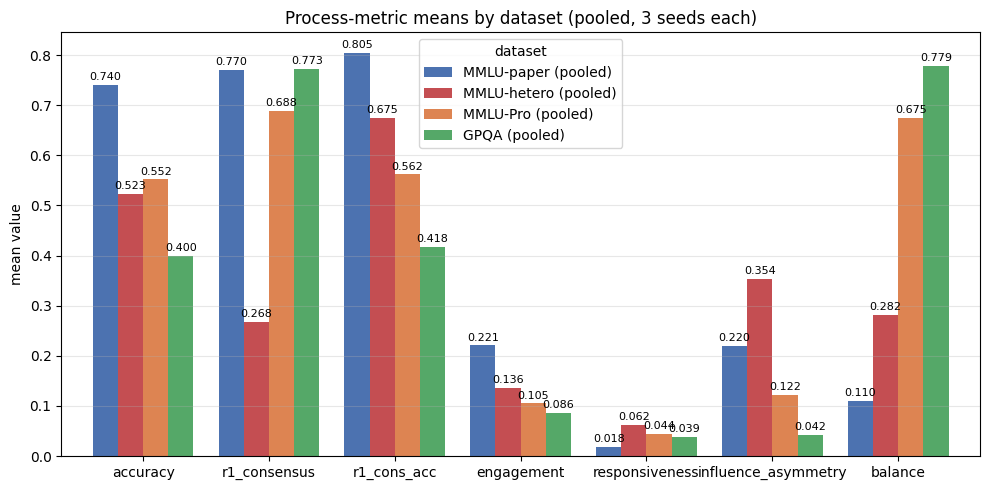

In [63]:
## Plot 3 — metric means by dataset (grouped bar chart from pooled_table)
import matplotlib.pyplot as plt

mean_cols = ['accuracy', 'r1_consensus','r1_cons_acc' ] + [f'{m}_mean' for m in METRICS]
print(mean_cols)
print(pooled_table.head())
plot_df = pooled_table[mean_cols].astype(float)
plot_df.columns = ['accuracy', 'r1_consensus','r1_cons_acc'] +METRICS            # x-axis labels: the four metrics
plot_df = plot_df.T                  # rows = metrics, columns = datasets (bar groups)

ax = plot_df.plot(kind='bar', figsize=(10, 5), width=0.8,
                  color={'MMLU-paper (pooled)': '#4C72B0', 'MMLU-hetero (pooled)': '#C44E52', 'GPQA (pooled)': '#55A868', 'MMLU-Pro (pooled)': '#DD8452'})
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
ax.set_xticklabels(['accuracy', 'r1_consensus','r1_cons_acc'] +METRICS, rotation=0)
ax.set_ylabel('mean value')
ax.set_title('Process-metric means by dataset (pooled, 3 seeds each)')
ax.legend(title='dataset')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 4 — Consensus rate & consensus accuracy by round

For each round, **consensus rate** = fraction of debates where all 3 agents agree; **consensus accuracy** = among those consensus debates, fraction where the agreed answer is correct. Grouped bars by dataset.

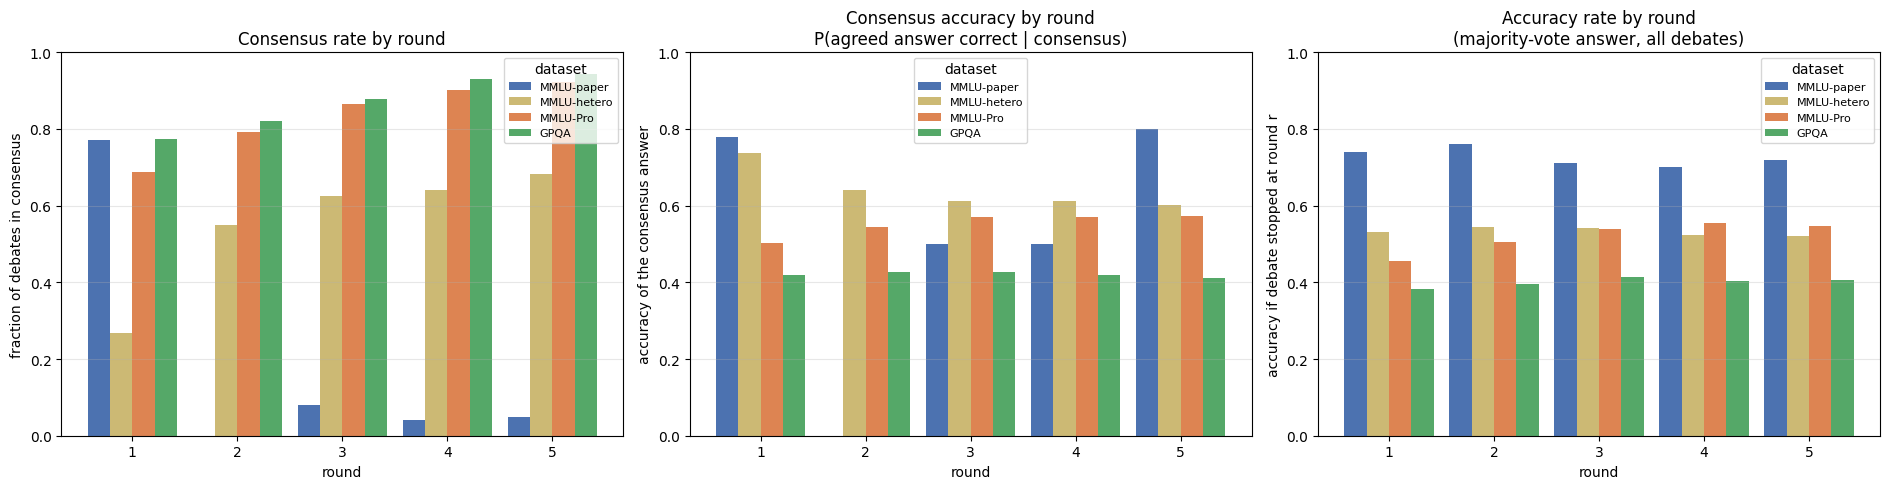

Consensus RATE by round:


,MMLU-paper,MMLU-hetero,MMLU-Pro,GPQA
round,,,,
1,0.77,0.268,0.688,0.773
2,0.00,0.550,0.792,0.820
3,0.08,0.624,0.865,0.877
4,0.04,0.641,0.902,0.930
5,0.05,0.681,0.923,0.943


Consensus ACCURACY by round:


,MMLU-paper,MMLU-hetero,MMLU-Pro,GPQA
round,,,,
1,0.779,0.738,0.504,0.418
2,NaN,0.640,0.545,0.427
3,0.500,0.613,0.570,0.426
4,0.500,0.613,0.571,0.419
5,0.800,0.601,0.572,0.410


ACCURACY RATE by round (majority-vote, all debates):


,MMLU-paper,MMLU-hetero,MMLU-Pro,GPQA
round,,,,
1,0.74,0.530,0.455,0.383
2,0.76,0.544,0.505,0.397
3,0.71,0.540,0.540,0.413
4,0.70,0.523,0.553,0.403
5,0.72,0.520,0.547,0.407


In [64]:
## Plot 4 — consensus rate, consensus accuracy, and accuracy-by-round, per dataset
import matplotlib.pyplot as plt

_HET = 'C:/Proj1/docs/data/mmlu_hetero_cpu/seed_{}/qwen_mmlu_pro_debate_traces.xlsx'
_COOP = 'C:/Proj1/docs/data/mmlu_original_cpu/seed_7/qwen_mmlu_pro_debate_traces.xlsx'
POOL_FILES = {
    'MMLU-paper': ['qwen_mmlu_faithful_s7.xlsx'],
    # 'MMLU-7B-coop': [_COOP],
    'MMLU-hetero': [_HET.format(7), _HET.format(17), _HET.format(42)],
    'MMLU-Pro':   ['baseline_v2_mmlu-pro_s7.xlsx', 'baseline_v2_mmlu-pro_s17.xlsx', 'baseline_v2_mmlu-pro_s42.xlsx'],
    'GPQA':       ['baseline_v2_gpqa_s7.xlsx', 'baseline_v2_gpqa_s17.xlsx', 'baseline_v2_gpqa_s42.xlsx'],
}

def per_round_stats(paths):
    """Pooled per-round stats across paths (answers forward-filled):
      - consensus rate      : fraction of debates where all 3 agents agree at round r
      - consensus accuracy  : P(agreed answer correct | consensus at round r)
      - accuracy by round   : accuracy of the MAJORITY-VOTE answer at round r, over ALL debates
                              ("if the debate stopped at round r, how accurate would it be")
    """
    rec = {}  # round -> [n_debates, n_consensus, n_consensus_correct, n_majority_correct]
    for path in paths:
        df = pd.read_excel(path, sheet_name='Debate_Traces')
        rounds = sorted({int(m.group(1)) for c in df.columns if (m := re.match(r'R(\d+) Agent1 Answer', c))})
        for _, r in df.iterrows():
            correct = str(r.get('Correct Answer')).strip()
            last = {a: None for a in AGENTS}
            for rd in rounds:
                ans = []
                for ag in AGENTS:
                    a = r.get(f'R{rd} {ag} Answer')
                    a = last[ag] if pd.isna(a) else str(a).strip()
                    last[ag] = a
                    ans.append(a)
                present = [a for a in ans if a]
                rec.setdefault(rd, [0, 0, 0, 0])
                rec[rd][0] += 1
                if present:
                    majority = Counter(present).most_common(1)[0][0]   # plurality answer this round
                    if majority == correct:
                        rec[rd][3] += 1
                if len(present) == 3 and len(set(present)) == 1:       # unanimous consensus
                    rec[rd][1] += 1
                    if present[0] == correct:
                        rec[rd][2] += 1
    rounds = sorted(rec)
    rate = {rd: rec[rd][1] / rec[rd][0] for rd in rounds}
    cons_acc = {rd: (rec[rd][2] / rec[rd][1] if rec[rd][1] else np.nan) for rd in rounds}
    maj_acc = {rd: rec[rd][3] / rec[rd][0] for rd in rounds}
    return rate, cons_acc, maj_acc

rate_by_round, cons_acc_by_round, acc_by_round = {}, {}, {}
for pool, paths in POOL_FILES.items():
    cr, ca, ma = per_round_stats(paths)
    rate_by_round[pool] = cr
    cons_acc_by_round[pool] = ca
    acc_by_round[pool] = ma
consensus_rate_by_round = pd.DataFrame(rate_by_round); consensus_rate_by_round.index.name = 'round'
consensus_acc_by_round = pd.DataFrame(cons_acc_by_round); consensus_acc_by_round.index.name = 'round'
accuracy_by_round = pd.DataFrame(acc_by_round); accuracy_by_round.index.name = 'round'

colors = {'MMLU-paper': '#4C72B0', 'MMLU-hetero': '#CCB974', 'MMLU-Pro': '#DD8452', 'GPQA': '#55A868'}
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
consensus_rate_by_round.plot(kind='bar', ax=axes[0], color=colors, width=0.85)
axes[0].set_title('Consensus rate by round')
axes[0].set_ylabel('fraction of debates in consensus'); axes[0].set_ylim(0, 1)
consensus_acc_by_round.plot(kind='bar', ax=axes[1], color=colors, width=0.85)
axes[1].set_title('Consensus accuracy by round\nP(agreed answer correct | consensus)')
axes[1].set_ylabel('accuracy of the consensus answer'); axes[1].set_ylim(0, 1)
accuracy_by_round.plot(kind='bar', ax=axes[2], color=colors, width=0.85)
axes[2].set_title('Accuracy rate by round\n(majority-vote answer, all debates)')
axes[2].set_ylabel('accuracy if debate stopped at round r'); axes[2].set_ylim(0, 1)
for ax in axes:
    ax.set_xlabel('round'); ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3); ax.legend(title='dataset', fontsize=8)
fig.tight_layout(); plt.show()

print('Consensus RATE by round:'); display(consensus_rate_by_round.round(3))
print('Consensus ACCURACY by round:'); display(consensus_acc_by_round.round(3))
print('ACCURACY RATE by round (majority-vote, all debates):'); display(accuracy_by_round.round(3))